# 고혈압 예측 - CatBoost Threshold 조정

- 타겟: `고혈압유병` (0: 없음 / 1: 있음)
- 모델: CatBoost (베이스라인과 동일 파라미터)
- 데이터: x1_preprocessed.csv
- 개선 포인트: OOF proba 기반 최적 threshold 탐색
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [ ]:
import os
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"


# ── 경로 설정 ──────────────────────────────────────────────
INPUT_PATH = "/Users/Jiyeon/Desktop/final_project/ML/data/x1_preprocessed.csv"
NPY_DIR = "/Users/Jiyeon/Desktop/final_project/ML/outputs/oof"
RANDOM_STATE = 42

## 1. 데이터 로드

In [3]:
df = pd.read_csv(INPUT_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (6033, 32)


## 2. 피처 / 타겟 분리

In [4]:
TARGET = "고혈압유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병", "비만단계"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos
print(f"샘플 수: {len(y)}  |  정상: {neg}  |  고혈압: {pos}")
print(f"class_weights: {{0: 1.0, 1: {ratio:.4f}}}")

샘플 수: 6033  |  정상: 4353  |  고혈압: 1680
class_weights: {0: 1.0, 1: 2.5911}


## 3. Stratified 5-Fold CV — OOF proba 수집

In [5]:
params = dict(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights={0: 1.0, 1: ratio},
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= 0.5).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration_,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration_}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8502 | Recall: 0.8363 | F1: 0.6460 | best_iter: 129
  Fold 2 | AUC: 0.8538 | Recall: 0.8214 | F1: 0.6294 | best_iter: 72
  Fold 3 | AUC: 0.8758 | Recall: 0.8631 | F1: 0.6840 | best_iter: 94
  Fold 4 | AUC: 0.8282 | Recall: 0.7917 | F1: 0.6080 | best_iter: 124
  Fold 5 | AUC: 0.8855 | Recall: 0.8363 | F1: 0.6706 | best_iter: 141
  평균   | AUC: 0.8587±0.0226 | Recall: 0.8298±0.0261 | F1: 0.6476±0.0306


## OOF proba 저장 (.npy)

In [6]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_HTN_catboost_threshold.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
print(f"shape: {oof_array.shape}  (col0: oof_proba, col1: y_true)")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/outputs/oof/oof_proba_HTN_catboost_threshold.npy
shape: (6033, 2)  (col0: oof_proba, col1: y_true)
로드 확인: shape=(6033, 2), 일치=True


## 4. Threshold 탐색 (0.30 ~ 0.60)

In [7]:
thresholds = np.arange(0.30, 0.65, 0.05).round(2)
thr_results = []

print(f"{'Threshold':>10} {'Recall':>8} {'Precision':>10} {'F1':>8} {'FP':>6} {'FN':>6}")
print("-" * 55)
for t in thresholds:
    pred_t = (oof_proba >= t).astype(int)
    cm_t = confusion_matrix(y, pred_t)
    rec = recall_score(y, pred_t)
    prec = precision_score(y, pred_t)
    f1 = f1_score(y, pred_t)
    thr_results.append(
        {"threshold": t, "recall": rec, "precision": prec, "f1": f1, "fp": int(cm_t[0, 1]), "fn": int(cm_t[1, 0])}
    )
    marker = "  ◀ baseline" if t == 0.50 else ""
    print(f"{t:>10.2f} {rec:>8.4f} {prec:>10.4f} {f1:>8.4f} {cm_t[0, 1]:>6} {cm_t[1, 0]:>6}{marker}")

thr_df = pd.DataFrame(thr_results)
cond = thr_df[thr_df.recall >= 0.80]
best_row = cond.loc[cond.f1.idxmax()] if len(cond) > 0 else thr_df.loc[thr_df.f1.idxmax()]
BEST_THRESHOLD = best_row.threshold
print(
    f"\n★ Recall≥0.80 조건 하 F1 최고: threshold={BEST_THRESHOLD:.2f} | "
    f"Recall={best_row.recall:.4f} | F1={best_row.f1:.4f} | FP={best_row.fp}"
)

 Threshold   Recall  Precision       F1     FP     FN
-------------------------------------------------------
      0.30   0.9429     0.4571   0.6157   1881     96
      0.35   0.9286     0.4756   0.6290   1720    120
      0.40   0.9042     0.4937   0.6386   1558    161
      0.45   0.8744     0.5118   0.6457   1401    211
      0.50   0.8298     0.5304   0.6472   1234    286  ◀ baseline
      0.55   0.7827     0.5579   0.6515   1042    365
      0.60   0.7202     0.5891   0.6481    844    470

★ Recall≥0.80 조건 하 F1 최고: threshold=0.50 | Recall=0.8298 | F1=0.6472 | FP=1234.0


## 5. Threshold별 지표 시각화

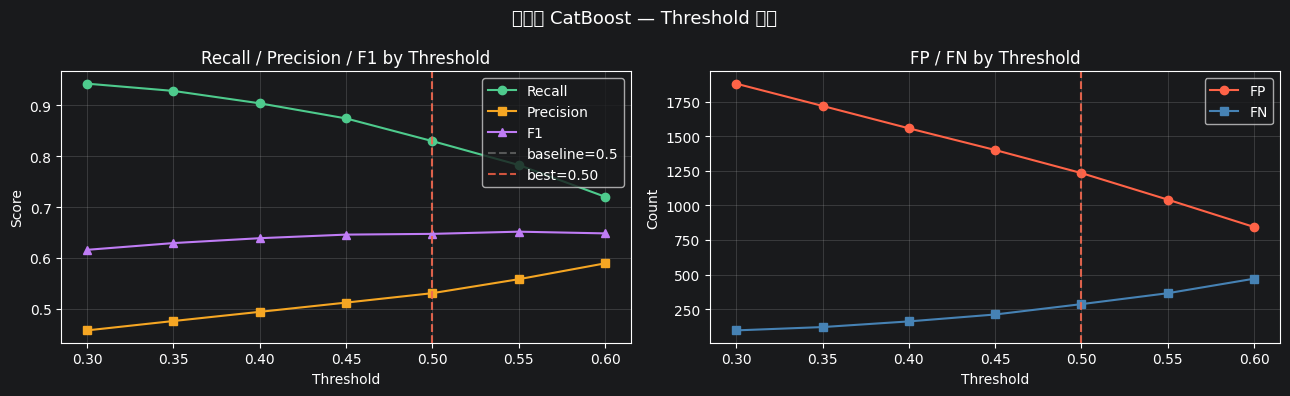

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thr_df.threshold, thr_df.recall, marker="o", label="Recall", color="#4ecb8d")
axes[0].plot(thr_df.threshold, thr_df.precision, marker="s", label="Precision", color="#f5a623")
axes[0].plot(thr_df.threshold, thr_df.f1, marker="^", label="F1", color="#bf7cf5")
axes[0].axvline(0.5, color="gray", linestyle="--", alpha=0.6, label="baseline=0.5")
axes[0].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8, label=f"best={BEST_THRESHOLD:.2f}")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Recall / Precision / F1 by Threshold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thr_df.threshold, thr_df.fp, marker="o", color="tomato", label="FP")
axes[1].plot(thr_df.threshold, thr_df.fn, marker="s", color="steelblue", label="FN")
axes[1].axvline(0.5, color="gray", linestyle="--", alpha=0.6)
axes[1].axvline(BEST_THRESHOLD, color="tomato", linestyle="--", alpha=0.8)
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Count")
axes[1].set_title("FP / FN by Threshold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("고혈압 CatBoost — Threshold 분석", fontsize=13)
plt.tight_layout()
plt.show()

## 6. 최적 Threshold 확정 & baseline 비교

In [9]:
pred_base = (oof_proba >= 0.50).astype(int)
pred_best = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_base = confusion_matrix(y, pred_base)
cm_best = confusion_matrix(y, pred_best)

print("=" * 55)
print(f"  {'지표':<12}  {'baseline (0.50)':>16}  {f'best ({BEST_THRESHOLD:.2f})':>10}  변화")
print("=" * 55)
for name, fn in [("Recall", recall_score), ("Precision", precision_score), ("F1-score", f1_score), ("AUC-ROC", None)]:
    if fn:
        v_base, v_best = fn(y, pred_base), fn(y, pred_best)
    else:
        v_base = v_best = roc_auc_score(y, oof_proba)
    d = v_best - v_base
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {name:<12}  {v_base:>16.4f}  {v_best:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {cm_base[0, 1]:>16}  {cm_best[0, 1]:>10}  {'▼' if cm_best[0, 1] < cm_base[0, 1] else '▲'} {abs(cm_best[0, 1] - cm_base[0, 1])}"
)
print(
    f"  {'FN':<12}  {cm_base[1, 0]:>16}  {cm_best[1, 0]:>10}  {'▼' if cm_best[1, 0] < cm_base[1, 0] else '▲'} {abs(cm_best[1, 0] - cm_base[1, 0])}"
)
print("=" * 55)
print(f"\n[분류 리포트 — threshold {BEST_THRESHOLD:.2f}]")
print(classification_report(y, pred_best, target_names=["정상(0)", "고혈압(1)"]))

  지표             baseline (0.50)  best (0.50)  변화
  Recall                  0.8298      0.8298  ─ 0.0000
  Precision               0.5304      0.5304  ─ 0.0000
  F1-score                0.6472      0.6472  ─ 0.0000
  AUC-ROC                 0.8585      0.8585  ─ 0.0000
  FP                        1234        1234  ▲ 0
  FN                         286         286  ▲ 0

[분류 리포트 — threshold 0.50]
              precision    recall  f1-score   support

       정상(0)       0.92      0.72      0.80      4353
      고혈압(1)       0.53      0.83      0.65      1680

    accuracy                           0.75      6033
   macro avg       0.72      0.77      0.73      6033
weighted avg       0.81      0.75      0.76      6033



## 7. Confusion Matrix 비교

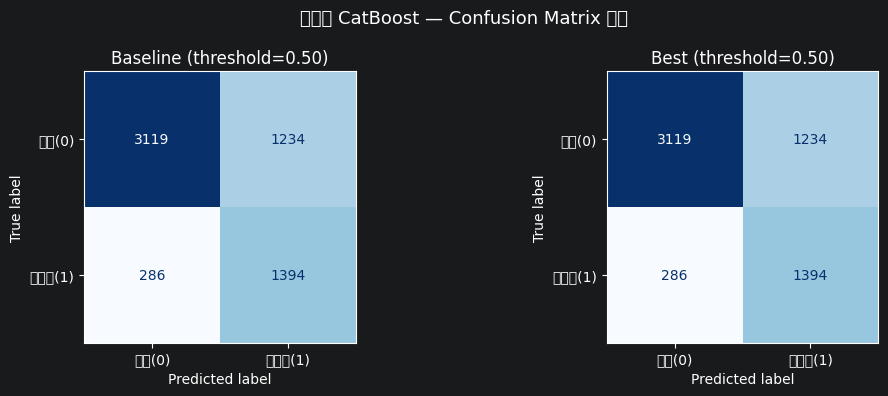

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, cm, title in zip(
    axes, [cm_base, cm_best], ["Baseline (threshold=0.50)", f"Best (threshold={BEST_THRESHOLD:.2f})"]
):
    ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "고혈압(1)"]).plot(cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(title)
plt.suptitle("고혈압 CatBoost — Confusion Matrix 비교", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Precision-Recall 커브

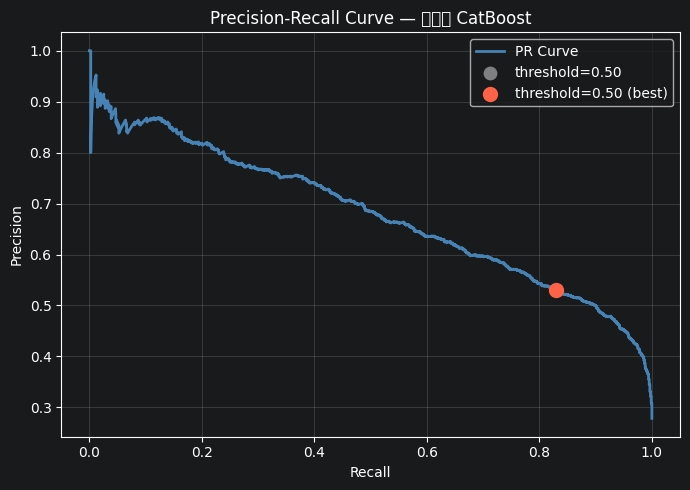

In [11]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y, oof_proba)
plt.figure(figsize=(7, 5))
plt.plot(rec_curve, prec_curve, color="steelblue", lw=2, label="PR Curve")
idx_base = np.argmin(np.abs(thr_curve - 0.50))
plt.scatter(rec_curve[idx_base], prec_curve[idx_base], s=80, color="gray", zorder=5, label="threshold=0.50")
idx_best = np.argmin(np.abs(thr_curve - BEST_THRESHOLD))
plt.scatter(
    rec_curve[idx_best],
    prec_curve[idx_best],
    s=100,
    color="tomato",
    zorder=5,
    label=f"threshold={BEST_THRESHOLD:.2f} (best)",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — 고혈압 CatBoost")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. DB 로그 저장

In [12]:
import sys

sys.path.insert(0, "/Users/Jiyeon/Desktop/final_project/ML")
from model_logger import ModelLogger

logger = ModelLogger("/Users/Jiyeon/Desktop/final_project/ML/model_result.db")
pred_final = (oof_proba >= BEST_THRESHOLD).astype(int)
cm_final = confusion_matrix(y, pred_final)

fi = pd.DataFrame({"feature": X.columns, "importance": model.get_feature_importance()}).sort_values(
    "importance", ascending=False
)

run_id = logger.log_run(
    target_var="고혈압",
    model_name="CatBoost",
    stage=f"threshold_{BEST_THRESHOLD:.2f}",
    hyperparams={
        "learning_rate": 0.05,
        "depth": 6,
        "iterations": 500,
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "eval_metric": "AUC",
        "early_stopping_rounds": 50,
    },
    data_info={"feature_count": X.shape[1], "train_test_split": "5-Fold CV", "scaling_method": "None"},
    oof_metrics={
        "accuracy": float((pred_final == y).mean()),
        "recall": recall_score(y, pred_final),
        "precision": precision_score(y, pred_final),
        "f1_score": f1_score(y, pred_final),
        "auc_roc": roc_auc_score(y, oof_proba),
        "cm": cm_final.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    threshold_results=thr_df.to_dict("records"),
    top_features=fi.set_index("feature")["importance"].head(15).to_dict(),
    note=f"Threshold {BEST_THRESHOLD:.2f} 조정. Recall>=0.80 조건 하 F1 최고점.",
)
print(f"저장 완료 → run_id: {run_id}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=11 | 고혈압 CatBoost (threshold_0.50)
저장 완료 → run_id: 11
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     11 2026-05-15 23:45:23        고혈압   CatBoost threshold_0.50 0.858479 0.829762   0.530441  0.647168  0.748052
     10 2026-05-15 19:09:58     이상지질혈증    XGBoost    optuna_shap 0.788701 0.835687   0.427867  0.565964  0.668987
      9 2026-05-15 19:00:15     이상지질혈증    XGBoost         optuna 0.803302 0.879974   0.421328  0.569825  0.656887
      8 2026-05-15 18:06:03     이상지질혈증    XGBoost threshold_0.45 0.787916 0.842747   0.412893  0.554242  0.649925
      7 2026-05-15 17:34:49         당뇨    XGBoost    optuna_shap 0.790561 0.839704   0.246829  0.381513  0.634013
      6 2026-05-15 17:24:13         당뇨    XGBoost         optuna 0.804071 0.831073   0.266403  0.403472  0.669650
      5 2026-05-15 17:02:27         당뇨    XGBoost threshold_0.45 0.783068 0.816276   0.253446  0.386795  0.652080
     